# **Assignment 2.1**: Human factors

## Task 1: Maps and Colormaps

In this task, the idea is to go over representations of data in maps and think about the usage of colors. 

In [1]:
import os #checking working directory
print(os.getcwd())

/Users/lauriprudant/LocalProjects/infoviz-course-2026/notebooks


In [2]:
%run ../helper.py

Importing necessary libraries (added geopandas to do work with maps)

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm

Loading world map

In [4]:
world = gpd.read_file("../data/ne_10m_admin_0_countries.zip")
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,Admin-0 country,0,4,China,CH1,1,2,Country,1,Macao S.A.R,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
254,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,Ashmore and Cartier Islands,...,None,None,None,None,None,None,None,None,None,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."
255,Admin-0 country,6,8,Bajo Nuevo Bank (Petrel Is.),BJN,0,2,Indeterminate,1,Bajo Nuevo Bank (Petrel Is.),...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-79.98929 15.79495, -79.98782 15.796..."
256,Admin-0 country,6,5,Serranilla Bank,SER,0,2,Indeterminate,1,Serranilla Bank,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-78.63707 15.86209, -78.64041 15.864..."


**Ectract South America from the file containing all country borders:**

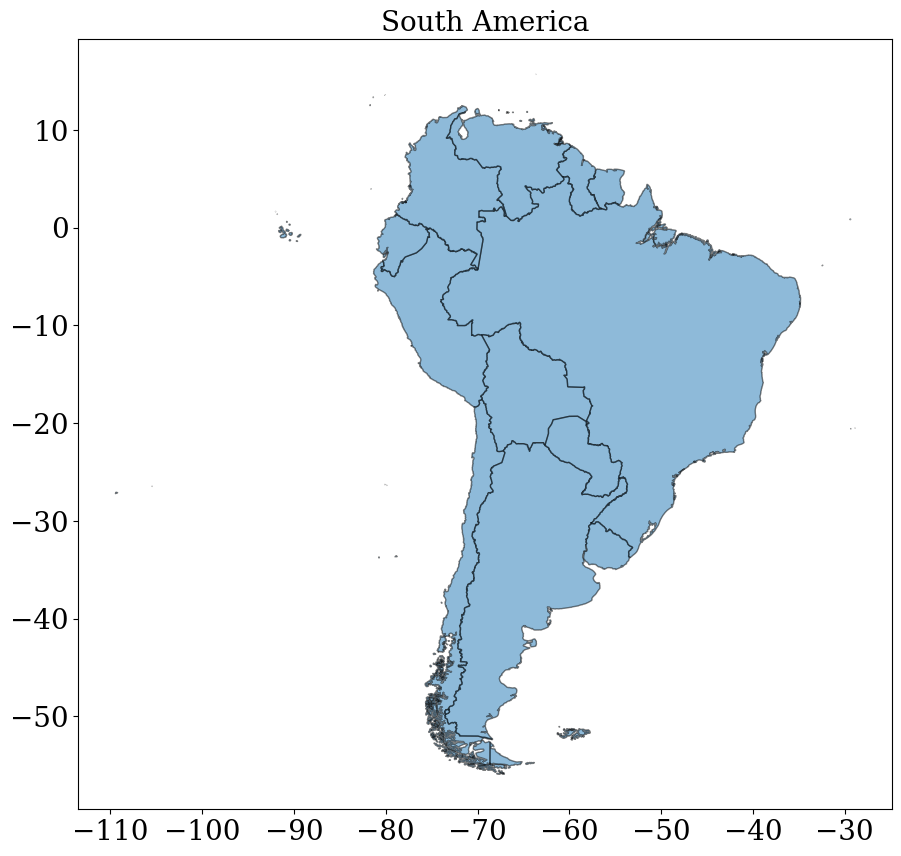

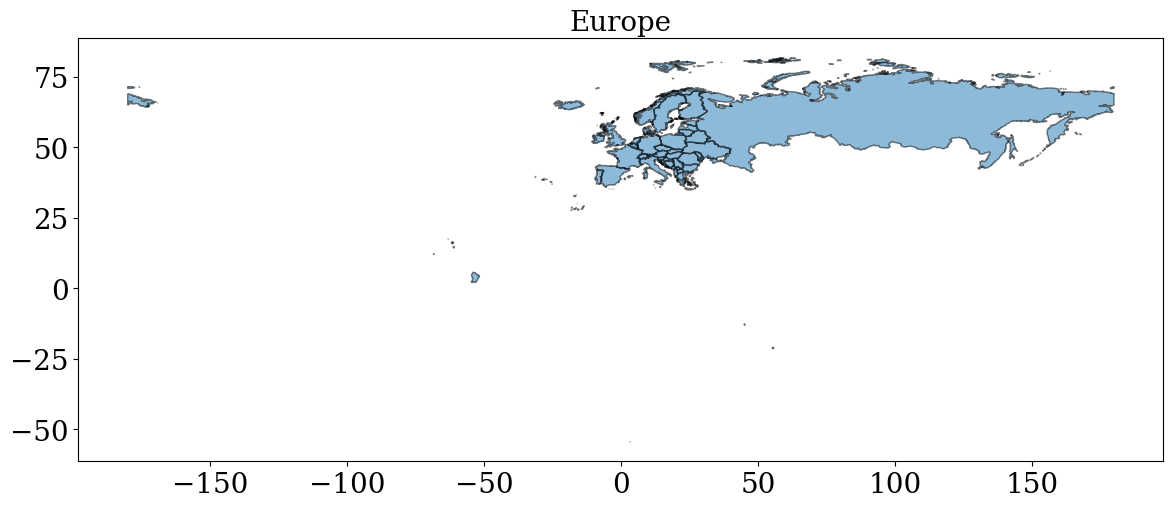

In [5]:
# Filter for South America
south_america = world[world['CONTINENT'] == 'South America']

# Filter for Europe
europe = world[world['CONTINENT'] == 'Europe']

# Quick visualization 1
fig, ax = plt.subplots(figsize=(14, 10))
south_america.plot(ax=ax, alpha=0.5, edgecolor='k')
plt.title('South America')
plt.show()

# Quick visualization 2
fig, ax = plt.subplots(figsize=(14, 10))
europe.plot(ax=ax, alpha=0.5, edgecolor='k')
plt.title('Europe')
plt.show()

Importing UNIDO Competitive Industrial Index data:

In [6]:
df = pd.read_csv("../data/data1.csv")

**Creating first cloropleth map, test with South America:**

Latest year in data: 2023

Countries in Industrialization intensity index for 2023:
                                  Country     Value
55                            Afghanistan  0.145235
293                               Albania  0.123154
531                               Algeria  0.154350
769                                Angola  0.115745
1007                            Argentina  0.345698
...                                   ...       ...
35279  Venezuela (Bolivarian Republic of)  0.198132
35517                            Viet Nam  0.565731
35755                               Yemen  0.134735
35993                              Zambia  0.163624
36231                            Zimbabwe  0.161641

[153 rows x 2 columns]


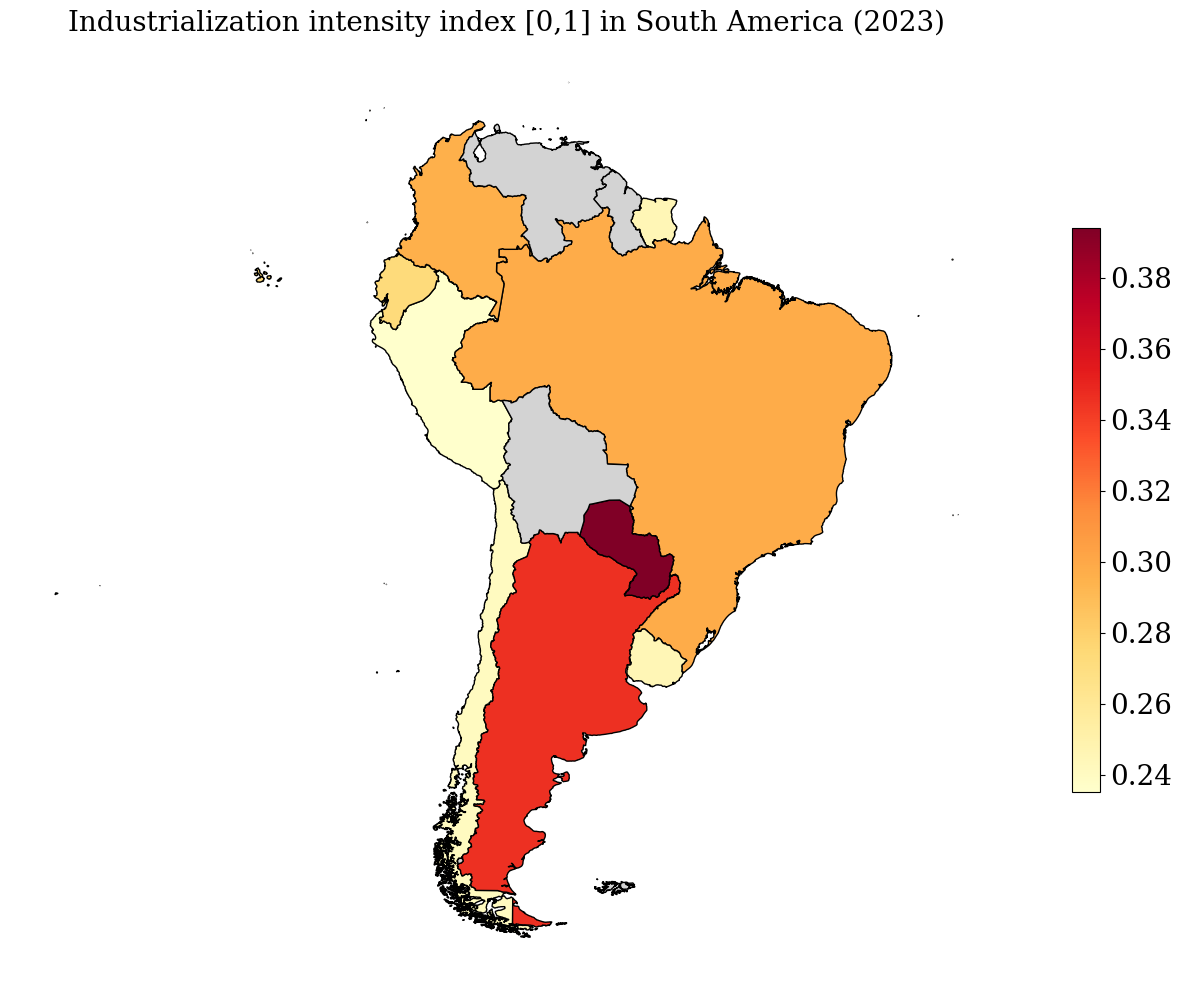

In [7]:
# Get the latest year
latest_year = df['Year'].max()
print(f"Latest year in data: {latest_year}")

# Filter for latest year and a specific variable (e.g., CIP score)
variable_to_map = 'Industrialization intensity index'  # Change this to any variable you want
latest_data = df[(df['Year'] == latest_year) & (df['Variable'] == variable_to_map)][['Country', 'Value']]

print(f"\nCountries in {variable_to_map} for {latest_year}:")
print(latest_data)

# Merge the data with the shapefile
south_america_merged = south_america.merge(latest_data, left_on='NAME', right_on='Country', how='left')

# Create the choropleth map
fig, ax = plt.subplots(figsize=(14, 10))
south_america_merged.plot(
    column='Value',
    ax=ax,
    legend=True,
    legend_kwds={
        'orientation': 'vertical',
        'shrink': 0.6,
    },
    cmap='YlOrRd',
    edgecolor='k',
    missing_kwds={'facecolor': 'lightgrey'}
)


plt.title(f'{variable_to_map} [0,1] in South America ({latest_year})')
plt.axis('off')
plt.tight_layout()
plt.show()

**South America has missing country Guyana and too few countries. Second cloropleth map, moving to Europe:**

Latest year in data: 2023

Countries in Medium- and high-tech manufactured exports share in total manufactured exports for 2023:
                                  Country     Value
97                            Afghanistan  0.003410
335                               Albania  0.186143
573                               Algeria  0.039488
811                                Angola  0.233716
1049                            Argentina  0.444910
...                                   ...       ...
35321  Venezuela (Bolivarian Republic of)  0.096520
35559                            Viet Nam  0.594966
35797                               Yemen  0.002451
36035                              Zambia  0.328582
36273                            Zimbabwe  0.168322

[153 rows x 2 columns]


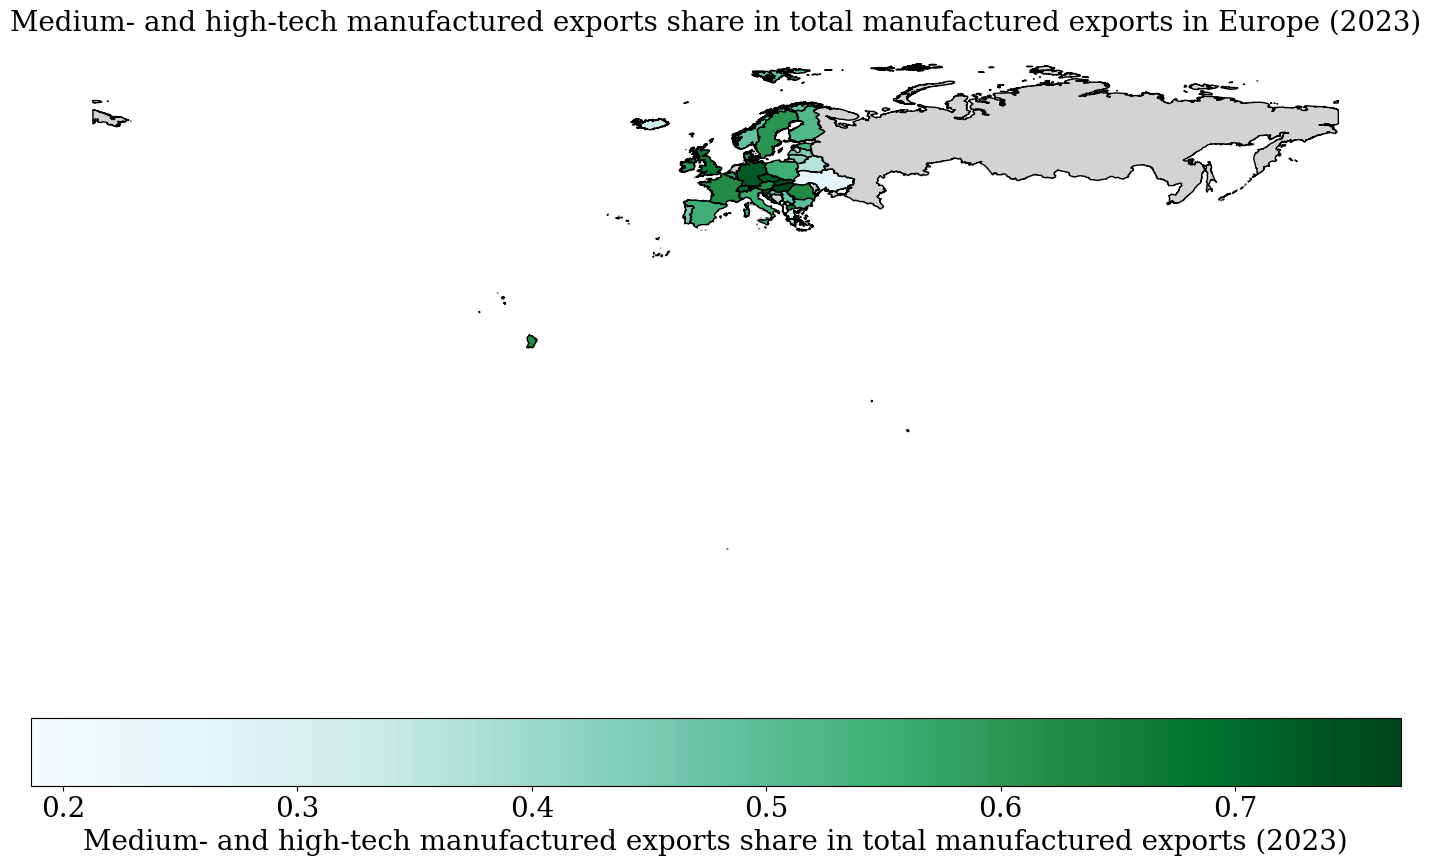

In [8]:
# Get the latest year
latest_year = df['Year'].max()
print(f"Latest year in data: {latest_year}")

# Filter for latest year and a specific variable (e.g., CIP score)
variable_to_map = 'Medium- and high-tech manufactured exports share in total manufactured exports'  # Change this to any variable you want
latest_data = df[(df['Year'] == latest_year) & (df['Variable'] == variable_to_map)][['Country', 'Value']]

print(f"\nCountries in {variable_to_map} for {latest_year}:")
print(latest_data)

# Merge the data with the shapefile
europe_merged = europe.merge(latest_data, left_on='NAME', right_on='Country', how='left')

# Create the choropleth map
fig, ax = plt.subplots(figsize=(14, 10))
europe_merged.plot(
    column='Value',
    ax=ax,
    legend=True,
    legend_kwds={'label': f'{variable_to_map} ({latest_year})', 'orientation': 'horizontal'},
    cmap='BuGn',  # Sequential colormap
    edgecolor='k',
    missing_kwds={'facecolor': 'lightgrey'}
)
plt.title(f'{variable_to_map} in Europe ({latest_year})')
plt.axis('off')
plt.tight_layout()
plt.show()

## Final map for Task1 part1
**Limiting analysis to only EU countries:**

Latest year in data: 2023


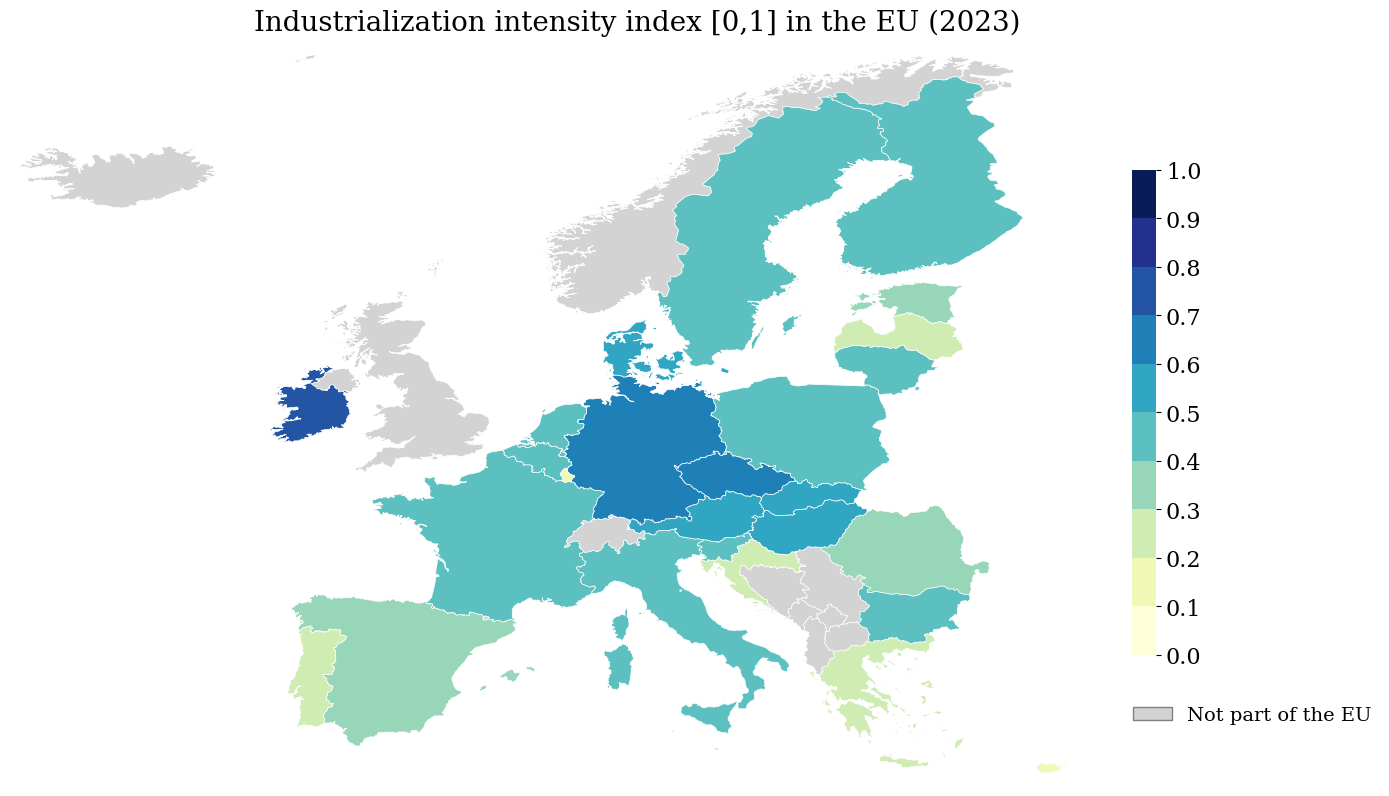

In [9]:
# EU 27 member states
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden'
]

# Filter shapefile to EU countries only
europe = world[world['NAME'].isin(eu_countries)].copy()

# Get the latest year
latest_year = df['Year'].max()
print(f"Latest year in data: {latest_year}")

# Filter for latest year and chosen variable
variable_to_map = 'Industrialization intensity index'
latest_data = df[(df['Year'] == latest_year) & (df['Variable'] == variable_to_map)][['Country', 'Value']].copy()

# Fix country name mismatches between CIP data and shapefile
latest_data['Country'] = latest_data['Country'].replace({
    'Czech Republic': 'Czechia',
    'Slovak Republic': 'Slovakia',
    'Netherlands (Kingdom of the)': 'Netherlands',
})

# Check for any unmatched EU countries
matched_names = set(latest_data['Country']) & set(europe['NAME'])
unmatched = set(europe['NAME']) - matched_names
if unmatched:
    print(f"EU countries with no data match: {unmatched}")

# Merge the data with the shapefile
europe_merged = europe.merge(latest_data, left_on='NAME', right_on='Country', how='left')

# Define bin edges and labels (shown in the colorbar next to map)
bins = np.arange(0, 1.1, 0.1)  # 0.0, 0.1, 0.2, ..., 1.0
n_bins = len(bins) - 1

# Create a discrete colormap from YlOrRd
base_cmap = plt.colormaps['YlGnBu'].resampled(n_bins)
norm = BoundaryNorm(bins, base_cmap.N)

# Non-EU European countries to show as grey background
non_eu_europe = [
    'Norway', 'Switzerland', 'United Kingdom', 'Iceland',
    'Serbia', 'Bosnia and Herz.', 'Montenegro', 'North Macedonia',
    'Albania', 'Kosovo',
    'Liechtenstein', 'Andorra', 'Monaco', 'San Marino'
]

europe_bg = world[world['NAME'].isin(non_eu_europe)].copy()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

# First layer: non-EU countries
europe_bg.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.5,
)

# Second layer: EU choropleth (to show both observed and unobserved European countries in the map)
europe_merged.plot(
    column='Value',
    ax=ax,
    legend=True,
    legend_kwds={
        'orientation': 'vertical',
        'shrink': 0.5,
        'ticks': bins,
        'format': '%.1f',
        'pad': -0.10,
    },
    cmap=base_cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'facecolor': 'lightgrey'}
)

# Style the colorbar: remove border, adjust font size
cbar = fig.axes[-1]
cbar.tick_params(labelsize=16)
cbar.spines[:].set_visible(False)

# Add grey patch legend for non-EU countries
legend_patch = Patch(facecolor='lightgrey', edgecolor='gray', label='Not part of the EU')
ax.legend(handles=[legend_patch], loc='upper right', 
          bbox_to_anchor=(1.1, 0.13), frameon=False, fontsize=14)

# Geographical limits within map
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

# Plotting the map and saving the created image
plt.title(f'{variable_to_map} [0,1] in the EU ({latest_year})')
plt.axis('off')
plt.tight_layout()
plt.tight_layout()
plt.savefig("../figures/cloropleth1eu.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print(world[world['NAME'].str.contains('Neth')]['NAME'].values)

['Netherlands']


In [11]:
print(world[world['NAME'].str.contains('Bos')]['NAME'].values)

['Bosnia and Herz.']


## Next, creating a diverging colormap from the same data

We create an average from the European values and compare how the values of the countries to that average

Latest year in data: 2023


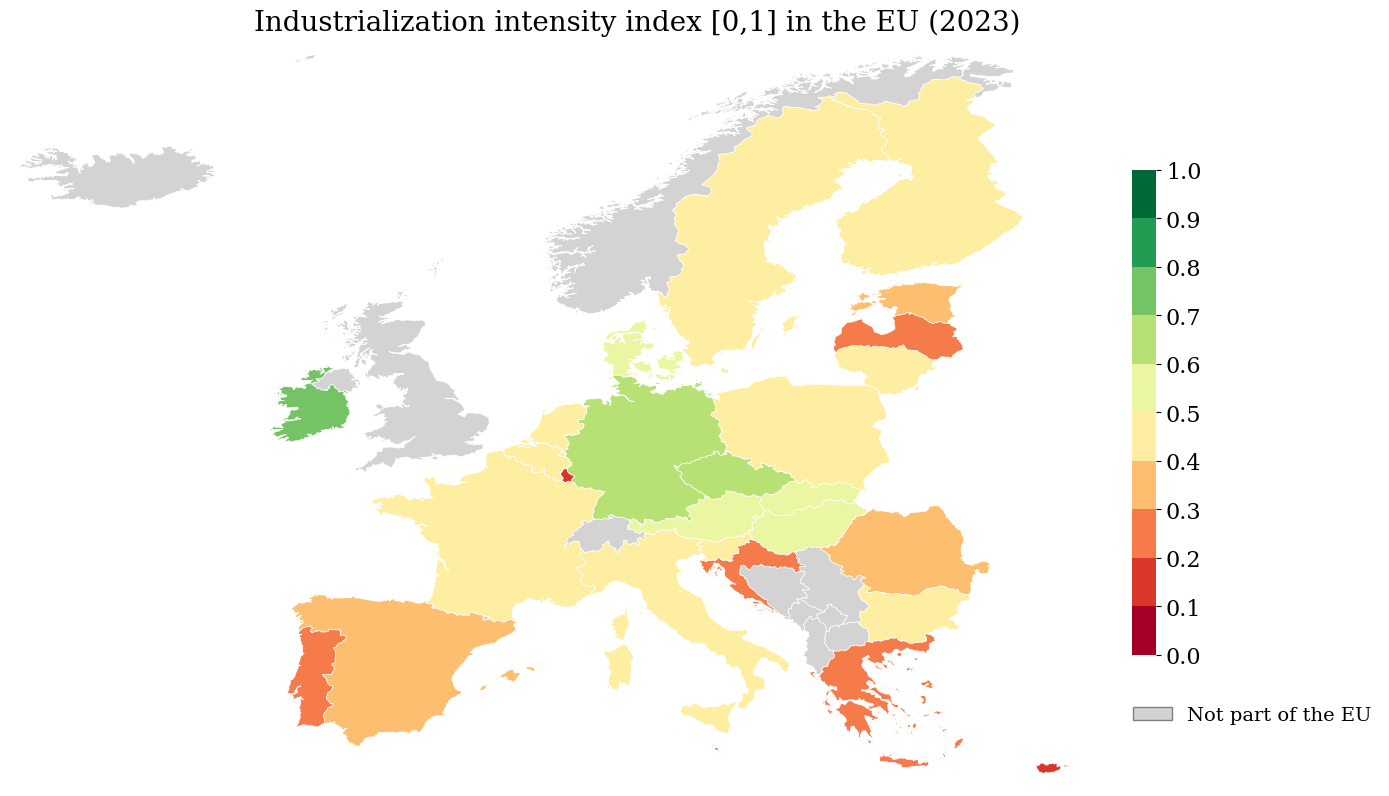

In [12]:
# EU 27 member states
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden'
]

# Filter shapefile to EU countries only
europe = world[world['NAME'].isin(eu_countries)].copy()

# Get the latest year
latest_year = df['Year'].max()
print(f"Latest year in data: {latest_year}")

# Filter for latest year and chosen variable
variable_to_map = 'Industrialization intensity index'
latest_data = df[(df['Year'] == latest_year) & (df['Variable'] == variable_to_map)][['Country', 'Value']].copy()

# Fix country name mismatches between CIP data and shapefile
latest_data['Country'] = latest_data['Country'].replace({
    'Czech Republic': 'Czechia',
    'Slovak Republic': 'Slovakia',
    'Netherlands (Kingdom of the)': 'Netherlands',
})

# Check for any unmatched EU countries
matched_names = set(latest_data['Country']) & set(europe['NAME'])
unmatched = set(europe['NAME']) - matched_names
if unmatched:
    print(f"EU countries with no data match: {unmatched}")

# Merge the data with the shapefile
europe_merged = europe.merge(latest_data, left_on='NAME', right_on='Country', how='left')

# Define bin edges and labels (shown in the colorbar next to map)
bins = np.arange(0, 1.1, 0.1)  # 0.0, 0.1, 0.2, ..., 1.0
n_bins = len(bins) - 1

# Create a discrete colormap from RdYlGn (the color scale, from matplotlib)
base_cmap = plt.colormaps['RdYlGn'].resampled(n_bins)
norm = BoundaryNorm(bins, base_cmap.N)

# Non-EU European countries to show as grey background
non_eu_europe = [
    'Norway', 'Switzerland', 'United Kingdom', 'Iceland',
    'Serbia', 'Bosnia and Herz.', 'Montenegro', 'North Macedonia',
    'Albania', 'Kosovo',
    'Liechtenstein', 'Andorra', 'Monaco', 'San Marino'
]

europe_bg = world[world['NAME'].isin(non_eu_europe)].copy()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

# First layer: non-EU countries
europe_bg.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.5,
)

# Second layer: EU choropleth
europe_merged.plot(
    column='Value',
    ax=ax,
    legend=True,
    legend_kwds={
        'orientation': 'vertical',
        'shrink': 0.5,
        'ticks': bins,
        'format': '%.1f',
        'pad': -0.10,
    },
    cmap=base_cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'facecolor': 'lightgrey'}
)

# Style the colorbar: remove border, adjust font size
cbar = fig.axes[-1]
cbar.tick_params(labelsize=16)
cbar.spines[:].set_visible(False)

# Add grey patch legend for non-EU countries
legend_patch = Patch(facecolor='lightgrey', edgecolor='gray', label='Not part of the EU')
ax.legend(handles=[legend_patch], loc='upper right', 
          bbox_to_anchor=(1.1, 0.13), frameon=False, fontsize=14)

# Geographical limits to area
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

# Plotting the map and saving the created image
plt.title(f'{variable_to_map} [0,1] in the EU ({latest_year})')
plt.axis('off')
plt.tight_layout()
plt.tight_layout()
#plt.savefig("../figures/cloropleth2eu.png", dpi=300, bbox_inches='tight')
plt.show()

**Another diverging colormap, first calculating the EU mean:**

Midpoint (EU mean): 0.420


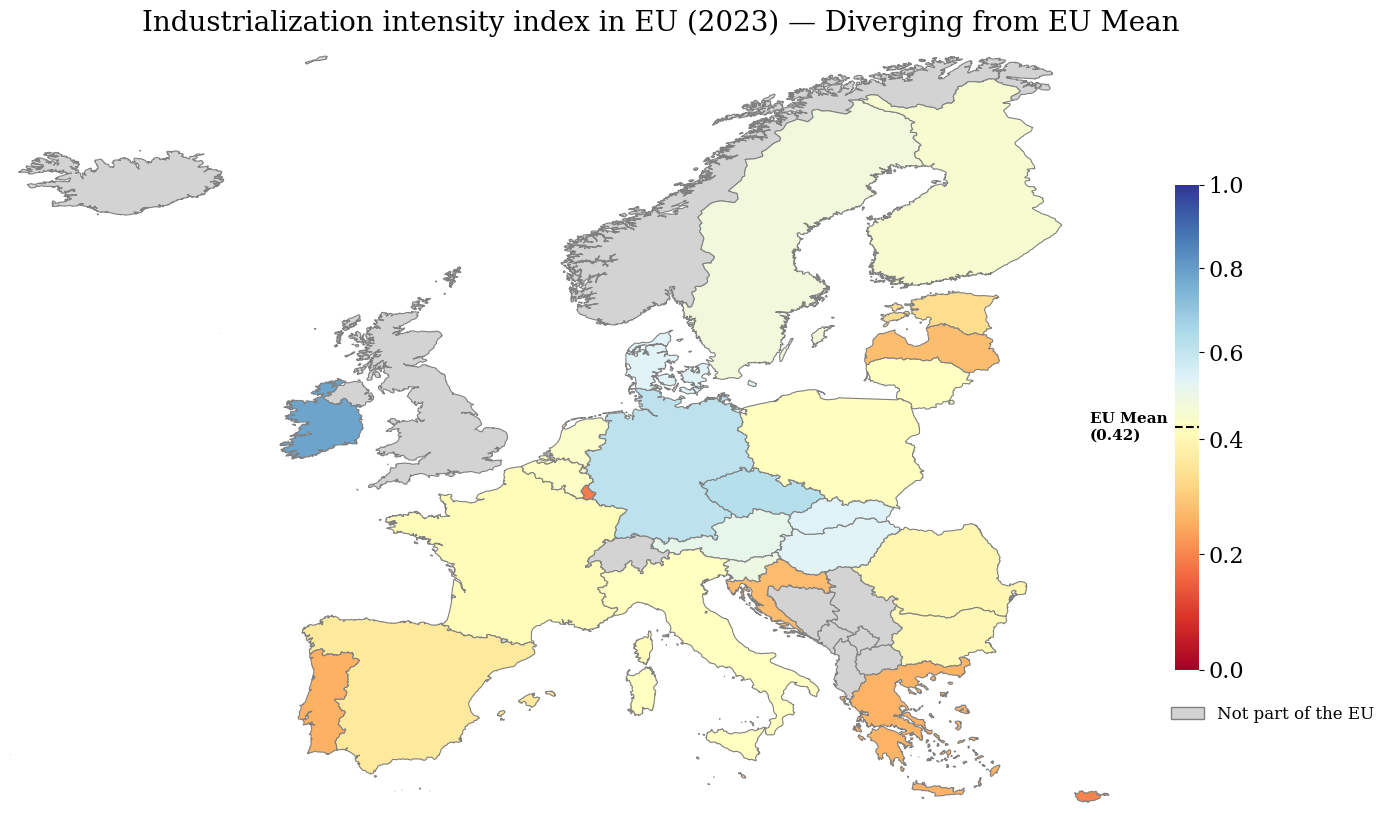

In [13]:
# Calculate the midpoint (EU mean)
midpoint = europe_merged['Value'].mean()
print(f"Midpoint (EU mean): {midpoint:.3f}")

# Diverging norm: fixed 0 to 1 range, centered on mean
div_norm = TwoSlopeNorm(
    vmin=0,
    vcenter=midpoint,
    vmax=1
)

fig, ax = plt.subplots(figsize=(14, 10))

# First layer: non-EU countries
europe_bg.plot(
    ax=ax,
    color='lightgray',
    edgecolor='gray',
    linewidth=0.8
)

# Second layer: EU choropleth with diverging colormap
europe_merged.plot(
    column='Value',
    ax=ax,
    legend=True,
    legend_kwds={
        #'label': f'{variable_to_map} ({latest_year})',
        'orientation': 'vertical',
        'shrink': 0.5,
        'pad': -0.10,
    },
    
    cmap='RdYlBu',
    norm=div_norm,
    edgecolor='gray',
    linewidth=0.8,
    missing_kwds={'facecolor': 'lightgrey'}
)

# Style the colorbar
cbar = fig.axes[-1]
cbar.tick_params(labelsize=16)
cbar.spines[:].set_visible(False)

# Add a horizontal line and label at the mean
cbar.axhline(y=midpoint, color='black', linewidth=1.5, linestyle='--')
cbar.text(-3.5, midpoint, f'EU Mean\n({midpoint:.2f})', 
          transform=cbar.get_yaxis_transform(),
          va='center', fontsize=11, fontweight='bold')

# Grey patch legend
from matplotlib.patches import Patch
legend_patch = Patch(facecolor='lightgrey', edgecolor='gray', label='Not part of the EU')
ax.legend(handles=[legend_patch], loc='upper right',
          bbox_to_anchor=(1.06, 0.16), frameon=False, fontsize=12)

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

plt.title(f'{variable_to_map} in EU ({latest_year}) — Diverging from EU Mean')
plt.axis('off')
plt.tight_layout()
plt.savefig("../figures/cloropleth2eu.png", dpi=300, bbox_inches='tight')
plt.show()

# **Task 2:** Heatmaps and Clustermaps

## **First,** regular heatmap presenting time series variables

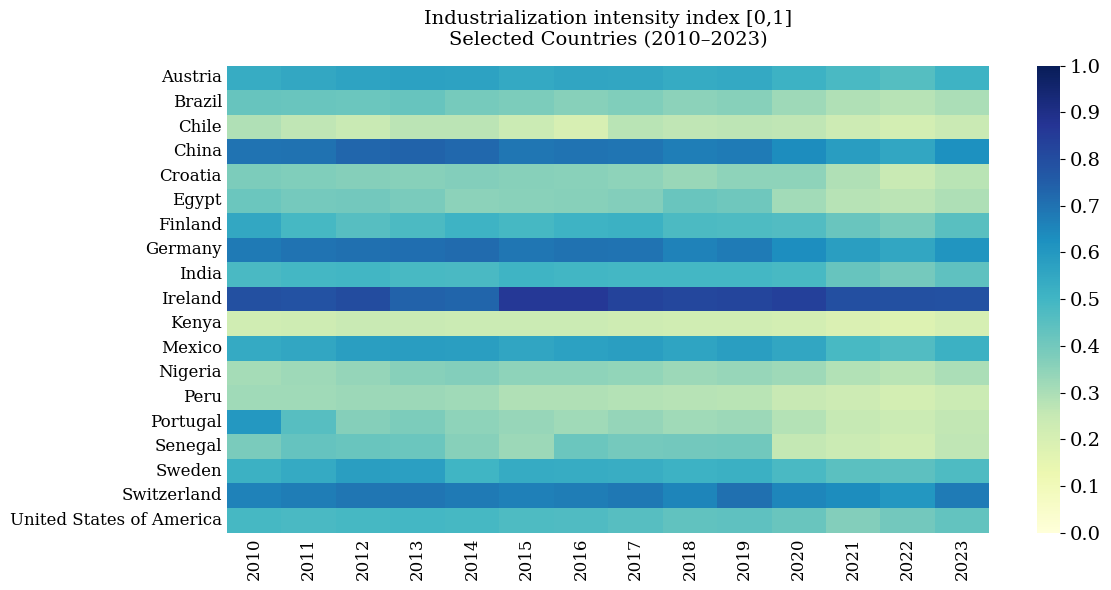

In [14]:
group = ['Germany', 'China', 'Ireland', 'United States of America', 
         'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico',
         'Ireland', 'Austria', 'Chile', 'Peru', 'Nigeria', 'Senegal', 'Egypt',
         'Kenya', 'Portugal', 'Croatia']

# Filter and pivot
df_sa_cip = df[(df['Country'].isin(group)) & (df['Variable'] == 'Industrialization intensity index')]
df_pivot = df_sa_cip.pivot(index='Country', columns='Year', values='Value')

# Sort alphabetically (as required by the assignment)
df_pivot = df_pivot.sort_index(ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

'''bins = np.arange(0, 1.1, 0.1)
n_bins = len(bins) - 1
base_cmap = plt.colormaps['YlGnBu'].resampled(n_bins)
norm = BoundaryNorm(bins, base_cmap.N)'''

# creating heatmap 
'''sns.heatmap(df_pivot, 
            xticklabels=1, 
            yticklabels=1, 
            cmap=base_cmap, #using created bins
            norm=norm,
            linewidths=0.5,
            linecolor='none',
            fmt='.3f',
            cbar_kws={#'label': 'Industrialization Intensity Index',
                      'ticks': bins, 
                      'format': '%.1f'})'''
sns.heatmap(df_pivot, 
            xticklabels=1, 
            yticklabels=1, 
            cmap='YlGnBu',
            vmin=0, #minimum value for the color scale
            vmax=1, #max value for color scale
            linewidths=0.5,
            linecolor='none',
            fmt='.3f',
            cbar_kws={#'label': 'Industrialization Intensity Index',
                      'ticks': bins, 
                      'format': '%.1f'})

#colorbar (legend) formatting
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.label.set_size(9)

#axis modification
ax.tick_params(axis='y', length=0, labelsize=12)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.set_ylabel('')
ax.set_xlabel('')

#plotting
plt.title("Industrialization intensity index [0,1]\nSelected Countries (2010–2023)",
          fontsize=14, fontweight='light', pad=15)
plt.tight_layout()
plt.savefig("../figures/heatmap_assignment3.png", dpi=300, bbox_inches='tight')
plt.show()

## **Then,** hierarchically clustered heatmap

Hierarchically clustered heatmaps map the data within clusters according to relationships seen in the data. 

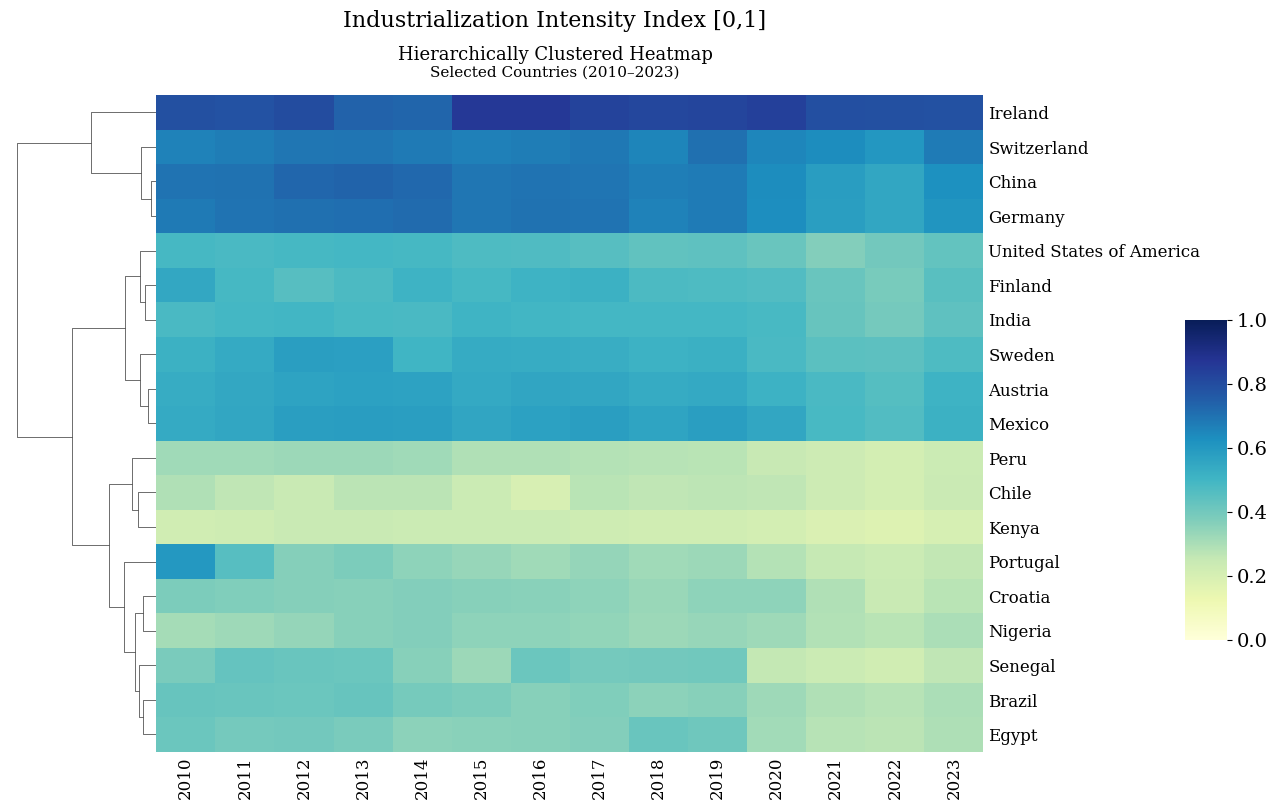

In [15]:
# Hierarchically clustered heatmap, seaborn command
g = sns.clustermap(
    df_pivot, #plotted data
    #method='ward', 
    metric='euclidean', #distance between data entries. Euclidean distance measures distance "as-the-crow-flies". Works when variables are in the same scale
    row_cluster=True, #clusters rows. Specifically asked in the assignment, as columns left unchanged to just represent time.
    col_cluster=False, #'False' to leave columns unchanged. 
    cmap='YlGnBu', #Same colorscale as in the previous colormap
    vmin=0, #minimum value for the color scale
    vmax=1, #max value for color scale
    linecolor='none', #no lines between the squares of the heatmap to see changes in levels
    figsize=(14, 8),
    dendrogram_ratio=(0.15, 0), #controls how much space of the figure the dendograms take
)

g.cax.set_position([0.85, 0.3, 0.03, 0.4])  # enforce position

g.fig.text(0.4, 1.06, "Industrialization Intensity Index [0,1]",
           fontsize=16, fontweight='light', ha='center', va='bottom')
g.fig.text(0.4, 1.02, "Hierarchically Clustered Heatmap",
           fontsize=13, fontweight='light', ha='center', va='bottom')
g.fig.text(0.4, 1.00, "Selected Countries (2010–2023)",
           fontsize=11, fontweight='light', ha='center', va='bottom')

cbar = g.ax_heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.label.set_size(9)

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='both', length=0, labelsize=12)

plt.savefig("../figures/clustermap_assignment3.png", dpi=300, bbox_inches='tight')
plt.show()